In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [30]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [31]:
df_sales = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

In [32]:
df_sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


# EDA

In [33]:
# shape of data set

df_sales.shape

(9994, 21)

In [34]:
df_sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [35]:
df_sales.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [36]:
# check for the missing values

df_sales.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [37]:
# columns and types
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [38]:
# basic statistics for numeric

df_sales.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [39]:
# basic statistics for categorical variables
df_sales.describe(include = 'object')

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1237,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2017-100111,9/5/2016,12/16/2015,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [40]:
# duplicate from dataset

df_sales.duplicated().sum()

0

In [41]:
# convert the text dates to real dates

df_sales["Order Date"] = pd.to_datetime(df_sales["Order Date"])
df_sales["Ship Date"] = pd.to_datetime(df_sales["Ship Date"])


In [42]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

# FEATURE ENGINEERING

In [ ]:
#add context to data 

In [45]:
# extract time features from the date variables

df_sales["Order Month"] = df_sales["Order Date"].dt.month
df_sales["Order Year"] = df_sales["Order Date"].dt.year
df_sales["Order Quarter"] = df_sales["Order Date"].dt.quarter



In [47]:
# determine the shipping delay in days

df_sales["Ship Delay"] = (df_sales["Ship Date"] - df_sales["Order Date"]).dt.days


In [49]:
# Calculate profit margin percentage
df_sales["Profit.Margin"] = (df_sales["Profit"] / df_sales["Sales"]) * 100

In [51]:
df_sales[["Order Month","Order Year","Order Quarter","Ship Delay","Profit.Margin"]]

,Order Month,Order Year,Order Quarter,Ship Delay,Profit.Margin
0,11,2016,4,3,16.00
1,11,2016,4,3,30.00
2,6,2016,2,4,47.00
3,10,2015,4,7,-40.00
4,10,2015,4,7,11.25
...,...,...,...,...,...
9989,1,2014,1,2,16.25
9990,2,2017,1,5,17.00
9991,2,2017,1,5,7.50
9992,2,2017,1,5,45.00


In [56]:
# quick check for new variables

print(" Max shipping delay:",df_sales["Ship Delay"].max(), "days")
print(" Min shipping delay:",df_sales["Ship Delay"].min(), "days")

 Max shipping delay: 7 days
 Min shipping delay: 0 days


In [57]:
# avarage profit margin 

print("The average profit margin:", round(df_sales["Profit.Margin"].mean(),2),"%")

The avarage profit margin: 12.03 %


In [58]:
print(f"Total column is: {df_sales.shape[1]}")

Total column is: 26


# SALES ANALYSIS

# SALES BY YEAR

In [65]:
yearly_sales = df_sales.groupby("Order Year")["Sales"].sum().reset_index()
print("THE PIVOT TABLE SHOW THE SALES TREND FROM 2014 TO 2017")
print()
print(yearly_sales)

THE PIVOT TABLE SHOW THE SALES TREND FROM 2014 TO 2017

   Order Year        Sales
0        2014  484247.4981
1        2015  470532.5090
2        2016  609205.5980
3        2017  733215.2552


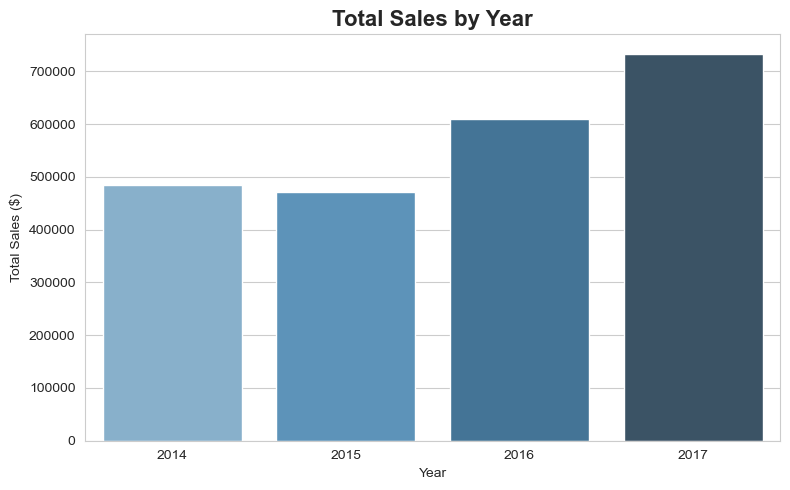

In [108]:
# plot

plt.figure(figsize = (8,5))
sns.barplot(data = yearly_sales, x = "Order Year", y = "Sales", palette = "Blues_d")

plt.title("Total Sales by Year", fontsize = 16, fontweight = "bold")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("chart1_sales_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

# monthly sales trend

In [67]:
# group sales by year and monthly together

monthly_sales = df_sales.groupby(["Order Year","Order Month"])["Sales"].sum().reset_index()
print("THE PIVOT TABLE TO SHOW THE TOTAL SALES ACROSS EACH MONTH")
print()
print(monthly_sales)

THE PIVOT TABLE TO SHOW THE TOTAL SALES ACROSS EACH MONTH

    Order Year  Order Month        Sales
0         2014            1   14236.8950
1         2014            2    4519.8920
2         2014            3   55691.0090
3         2014            4   28295.3450
4         2014            5   23648.2870
5         2014            6   34595.1276
6         2014            7   33946.3930
7         2014            8   27909.4685
8         2014            9   81777.3508
9         2014           10   31453.3930
10        2014           11   78628.7167
11        2014           12   69545.6205
12        2015            1   18174.0756
13        2015            2   11951.4110
14        2015            3   38726.2520
15        2015            4   34195.2085
16        2015            5   30131.6865
17        2015            6   24797.2920
18        2015            7   28765.3250
19        2015            8   36898.3322
20        2015            9   64595.9180
21        2015           10   31404.923

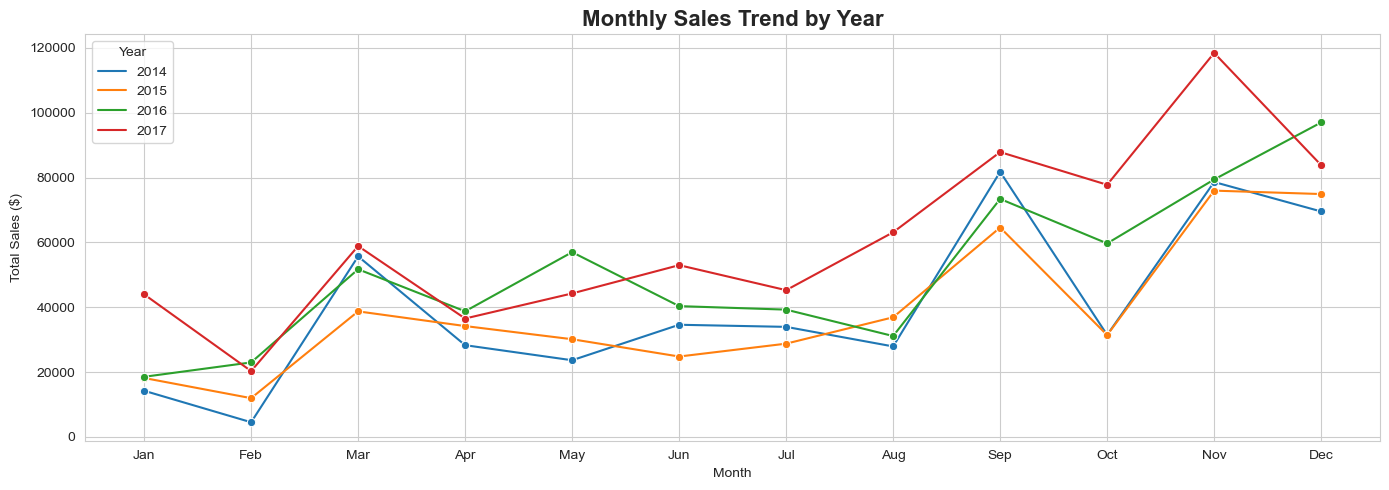

In [109]:
# plot

plt.figure(figsize = (14,5))
sns.lineplot(data = monthly_sales, x = "Order Month", y = "Sales", hue = "Order Year", marker = "o", palette = "tab10")

plt.title("Monthly Sales Trend by Year", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.legend(title="Year")
plt.tight_layout()
plt.savefig("chart2_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

# sales by category

In [70]:
# group sales by category

category_sales = df_sales.groupby("Category")["Sales"].sum().reset_index()
category_sales = category_sales.sort_values("Sales", ascending = False)
print("THE PIVOT TABLE TO SHOW THE SALES TREND BY CATEGORY")
print()
print(category_sales)

THE PIVOT TABLE TO SHOW THE SALES TREND BY CATEGORY

          Category        Sales
2       Technology  836154.0330
0        Furniture  741999.7953
1  Office Supplies  719047.0320


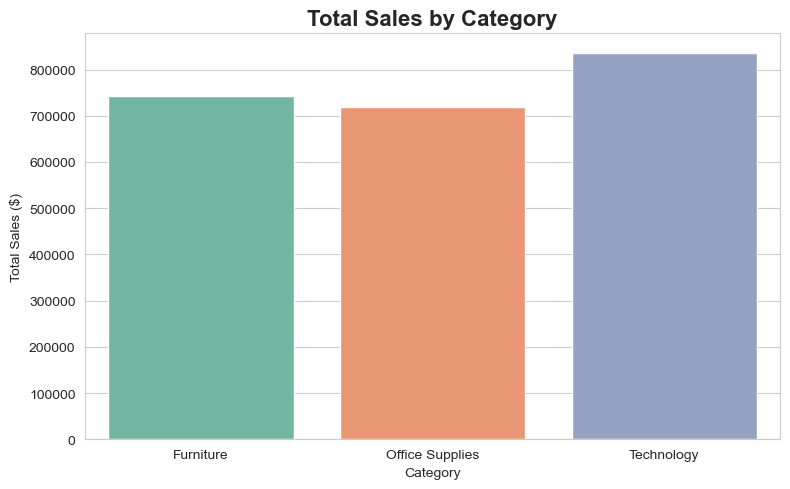

In [110]:
# plot

plt.figure(figsize = (8,5))
sns.barplot(data = category_sales, x = "Category", y = "Sales", palette = "Set2")
plt.title("Total Sales by Category", fontsize = 16, fontweight = "bold")
plt.xlabel("Category")
plt.ylabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("chart3_sales_category.png", dpi=150, bbox_inches="tight")
plt.show()

# sales by region

In [77]:
# group by region

region_sales = df_sales.groupby("Region")["Sales"].sum().reset_index()
region_sales = region_sales.sort_values("Sales", ascending = False)
print("THE PIVOT TABLE SHOWS THE SALES TREND ACROSS EACH REGION")
print()
print(region_sales)


THE PIVOT TABLE SHOWS THE SALES TREND ACROSS EACH REGION

    Region        Sales
3     West  725457.8245
1     East  678781.2400
0  Central  501239.8908
2    South  391721.9050


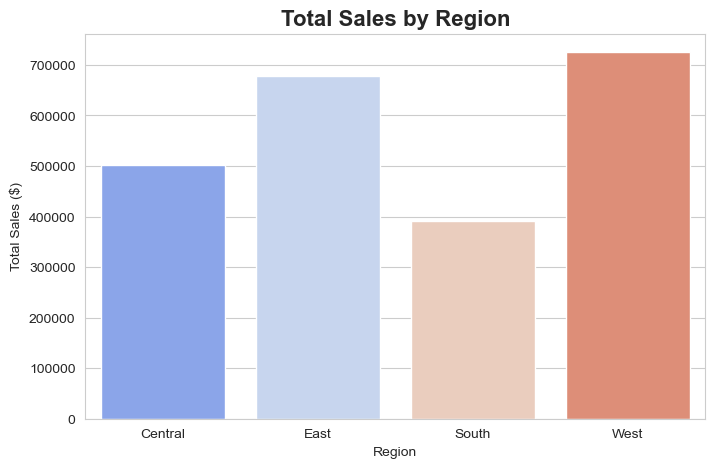

In [111]:
# plot
plt.figure(figsize = (8,5))
sns.barplot(data = region_sales, x = "Region", y = "Sales", palette = "coolwarm")
plt.title("Total Sales by Region", fontsize = 16, fontweight = "bold")
plt.xlabel("Region")
plt.ylabel("Total Sales ($)")
plt.savefig("chart4_sales_region.png", dpi=150, bbox_inches="tight")
plt.show()

# profit vs discount

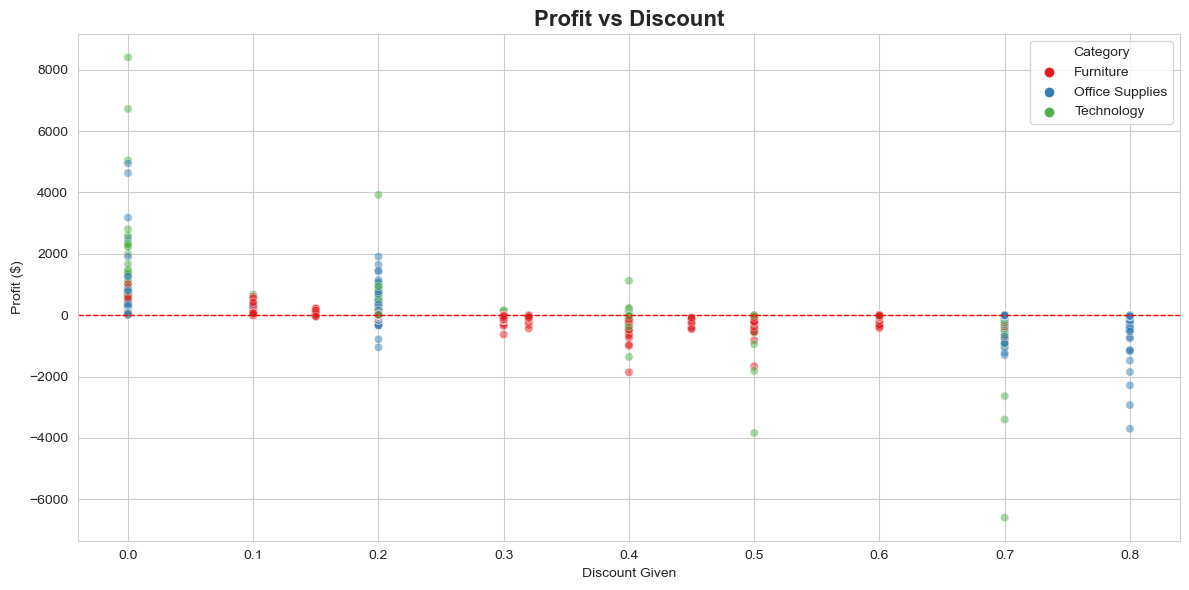

In [112]:
# scatter plot

sns.scatterplot(data  = df_sales, x = "Discount", y = "Profit",
               hue = "Category", alpha = 0.5, palette = "Set1")

plt.title("Profit vs Discount", fontsize=16, fontweight="bold")
plt.xlabel("Discount Given")
plt.ylabel("Profit ($)")
plt.axhline(y=0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig("chart5_profit_discount.png", dpi=150, bbox_inches="tight")
plt.show()

# custormer by sales

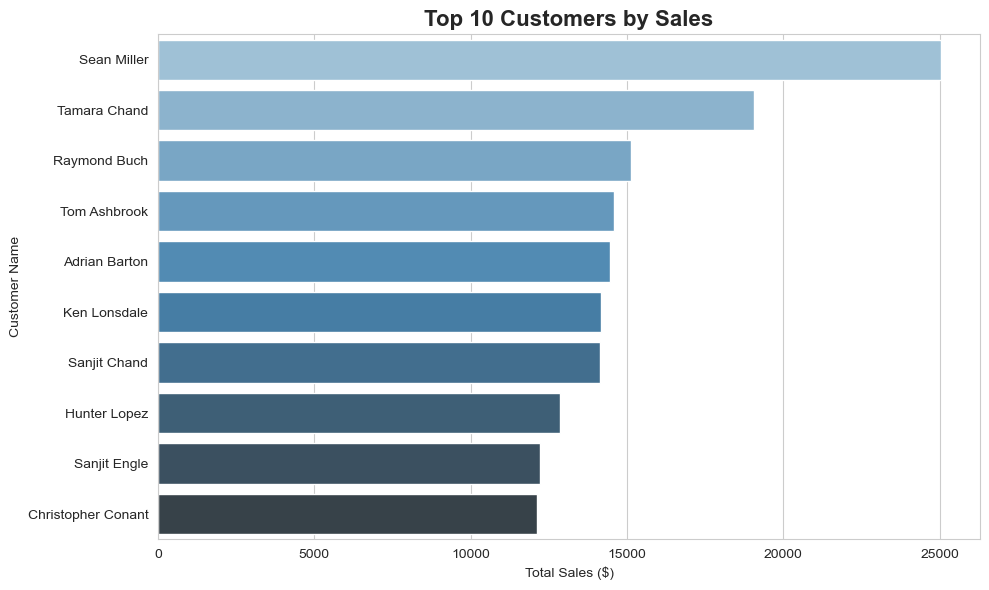

In [113]:
# Top 10 customers
top_customers = df_sales.groupby("Customer Name")["Sales"].sum()\
                  .reset_index()\
                  .sort_values("Sales", ascending=False)\
                  .head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_customers, x="Sales", y="Customer Name", palette="Blues_d")

plt.title("Top 10 Customers by Sales", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer Name")
plt.tight_layout()
plt.savefig("chart6_top_customers.png", dpi=150, bbox_inches="tight")
plt.show()

# PROFIT ANAYSIS

# profit by category

In [82]:
# Profit by Category
category_profit = df_sales.groupby("Category")["Profit"].sum().reset_index()
category_profit = category_profit.sort_values("Profit", ascending=False)
print("THE PIVOT TABLE SHOW THE PROFIT BY CATEGORY")
print(category_profit)

THE PIVOT TABLE SHOW THE PROFIT BY CATEGORY
          Category       Profit
2       Technology  145454.9481
1  Office Supplies  122490.8008
0        Furniture   18451.2728


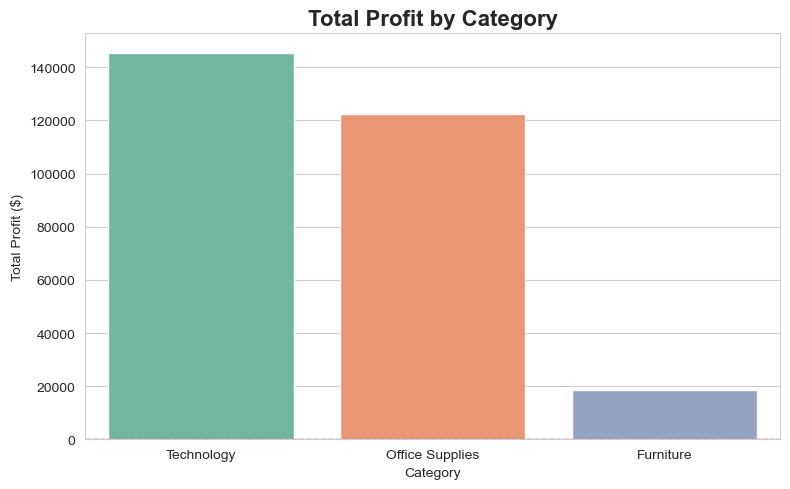

In [114]:
# plot
plt.figure(figsize=(8, 5))
bars = sns.barplot(data=category_profit, x="Category", 
                   y="Profit", palette="Set2")
plt.title("Total Profit by Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Profit ($)")
plt.axhline(y=0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig("chart7_profit_category.png", dpi=150, bbox_inches="tight")
plt.show()

In [86]:
# profit by sub category
sub_profit = df_sales.groupby("Sub-Category")["Profit"].sum()\
               .reset_index()\
               .sort_values("Profit", ascending=False)
print("THE PIVOT TABLE SHOW PROFIT BY SUB CATEGORY")
print(sub_profit)

THE PIVOT TABLE SHOW PROFIT BY SUB CATEGORY
   Sub-Category      Profit
6       Copiers  55617.8249
13       Phones  44515.7306
0   Accessories  41936.6357
12        Paper  34053.5693
3       Binders  30221.7633
5        Chairs  26590.1663
14      Storage  21278.8264
1    Appliances  18138.0054
9   Furnishings  13059.1436
7     Envelopes   6964.1767
2           Art   6527.7870
10       Labels   5546.2540
11     Machines   3384.7569
8     Fasteners    949.5182
15     Supplies  -1189.0995
4     Bookcases  -3472.5560
16       Tables -17725.4811


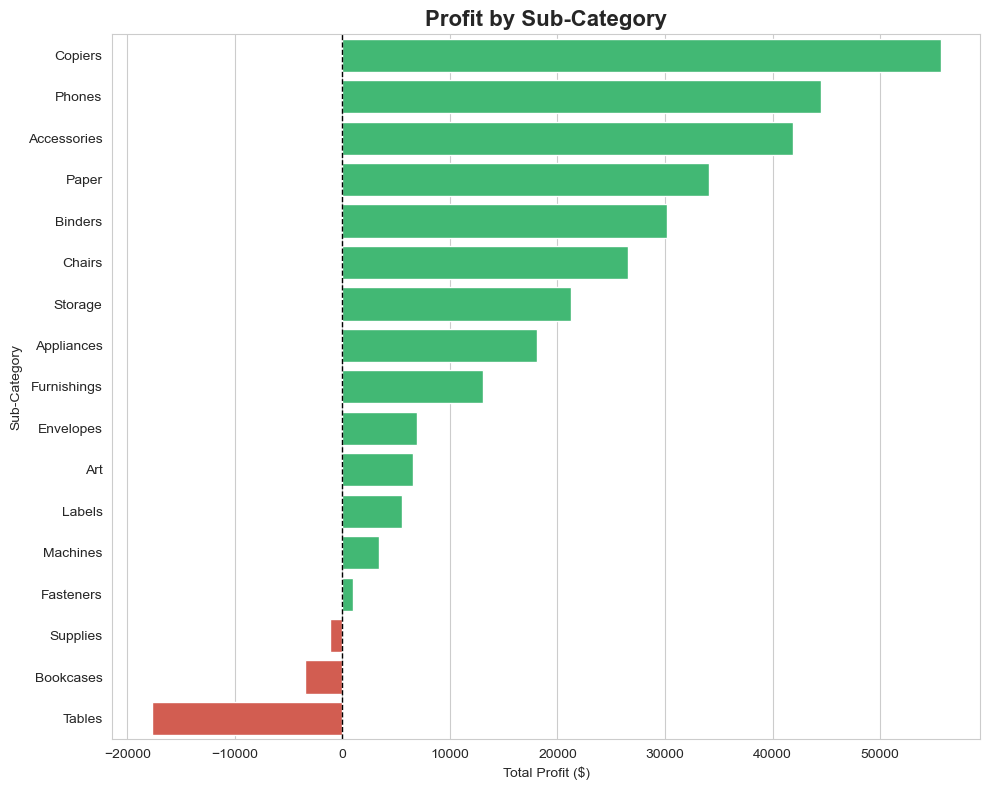

In [115]:
# plot
plt.figure(figsize=(10, 8))
colors = ["#2ecc71" if x > 0 else "#e74c3c" 
          for x in sub_profit["Profit"]]

sns.barplot(data=sub_profit, x="Profit", 
            y="Sub-Category", palette=colors)

plt.title("Profit by Sub-Category", fontsize=16, fontweight="bold")
plt.xlabel("Total Profit ($)")
plt.ylabel("Sub-Category")
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig("chart8_profit_subcategory.png", dpi=150, bbox_inches="tight")
plt.show()

# profit margin by segment

In [90]:
# Profit margin by segment
segment_profit = df_sales.groupby("Segment")["Profit.Margin"].mean()\
                   .reset_index()\
                   .sort_values("Profit.Margin", ascending=False)
print("THE PIVOT TABLE SHOW THE PROFIT MARGIN BY SEGMENT")
print(segment_profit)

THE PIVOT TABLE SHOW THE PROFIT MARGIN BY SEGMENT
       Segment  Profit.Margin
2  Home Office      14.286959
1    Corporate      12.120261
0     Consumer      11.204952


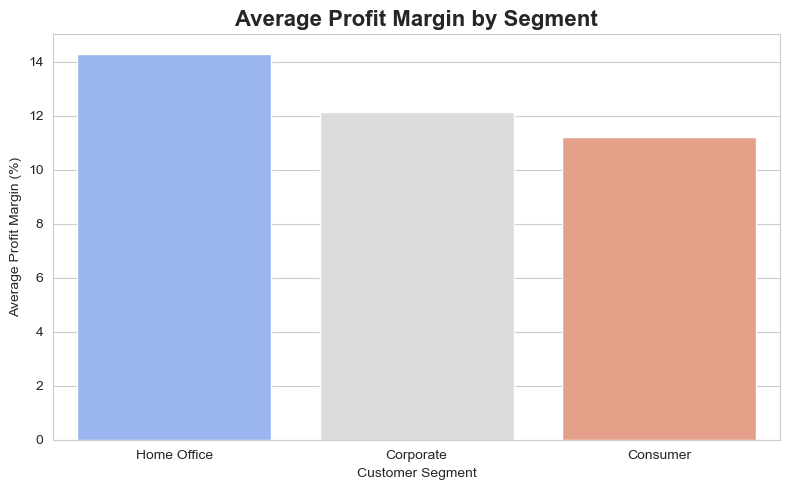

In [116]:
# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=segment_profit, x="Segment", 
            y="Profit.Margin", palette="coolwarm")

plt.title("Average Profit Margin by Segment", 
          fontsize=16, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Average Profit Margin (%)")
plt.tight_layout()
plt.savefig("chart9_profit_segment.png", dpi=150, bbox_inches="tight")
plt.show()

# CORRELATION ANALYSIS

In [95]:
# Discount vs profit Correlation
correlation  = df_sales["Discount"].corr(df_sales["Profit"])
print(f"Correlation between Discount and Profit: {correlation:.2f}")

if(correlation < 0):
    print("As the discount increase the profit tends to descrease")
elif(correlation > 0):
    print("As the discount decrease the profit tends to increase")
else:
    print("Dscount is not related by profit ")
    
        

Correlation between Discount and Profit: -0.22
As the discount increase the profit tends to descrease


In [98]:
# avarage profit at each discount level

discount_impact = df_sales.groupby("Discount")["Profit"].mean()\
                    .reset_index()\
                    .sort_values("Discount")
print("THE PIVOT TABLE SHOW THE EFFECT OF DISCOUNT ON PROFIT")
print(discount_impact)

THE PIVOT TABLE SHOW THE EFFECT OF DISCOUNT ON PROFIT
    Discount      Profit
0       0.00   66.900292
1       0.10   96.055074
2       0.15   27.288298
3       0.20   24.702572
4       0.30  -45.679636
5       0.32  -88.560656
6       0.40 -111.927429
7       0.45 -226.646464
8       0.50 -310.703456
9       0.60  -43.077212
10      0.70  -95.874060
11      0.80 -101.796797


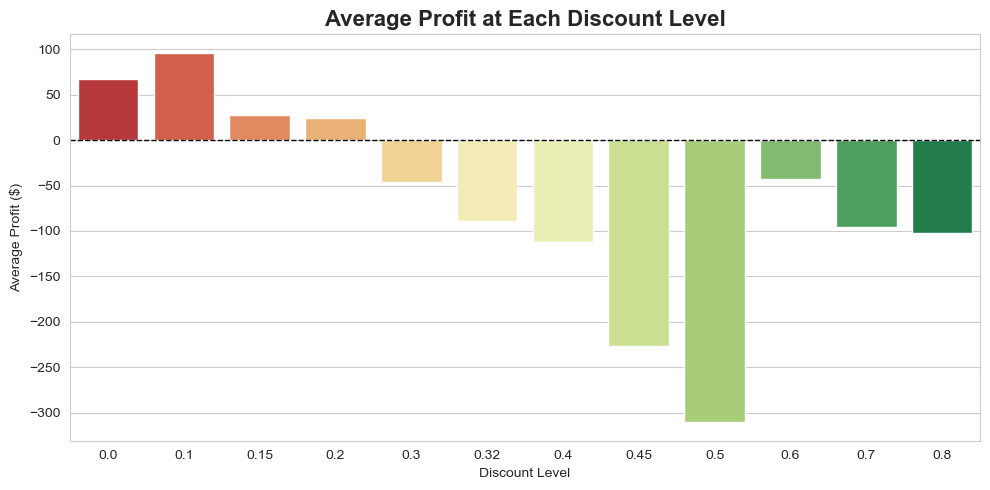

In [96]:
# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=discount_impact, x="Discount", 
            y="Profit", palette="RdYlGn")

plt.title("Average Profit at Each Discount Level", 
          fontsize=16, fontweight="bold")
plt.xlabel("Discount Level")
plt.ylabel("Average Profit ($)")
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

# avarage discount by category

In [100]:
discount_category = df_sales.groupby("Category")["Discount"].mean()\
                      .reset_index()\
                      .sort_values("Discount", ascending=False)
print("THE PIVOT TABLE SHOWS THE AVARAGE DISCOUNT BY CATEGORY")
print(discount_category)

THE PIVOT TABLE SHOWS THE AVARAGE DISCOUNT BY CATEGORY
          Category  Discount
0        Furniture  0.173923
1  Office Supplies  0.157285
2       Technology  0.132323


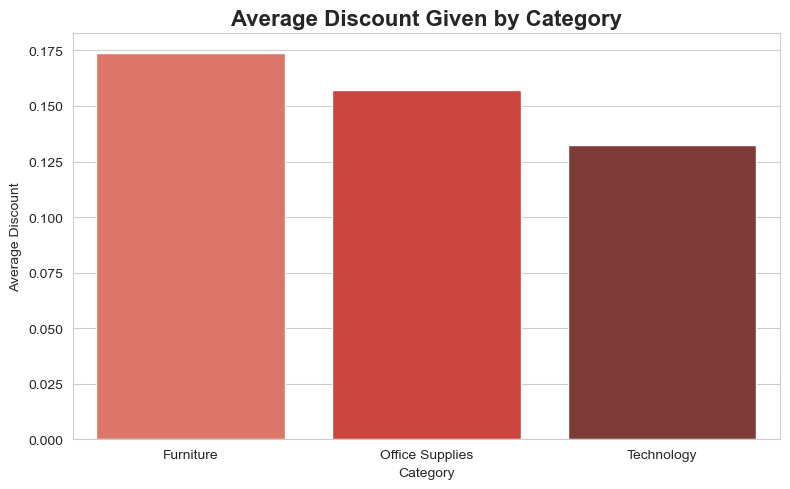

In [118]:
# plot
plt.figure(figsize=(8, 5))
sns.barplot(data=discount_category, x="Category", 
            y="Discount", palette="Reds_d")

plt.title("Average Discount Given by Category", 
          fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Average Discount")
plt.tight_layout()
plt.savefig("chart10_discount_impact.png", dpi=150, bbox_inches="tight")
plt.show()

# final summary dashbord

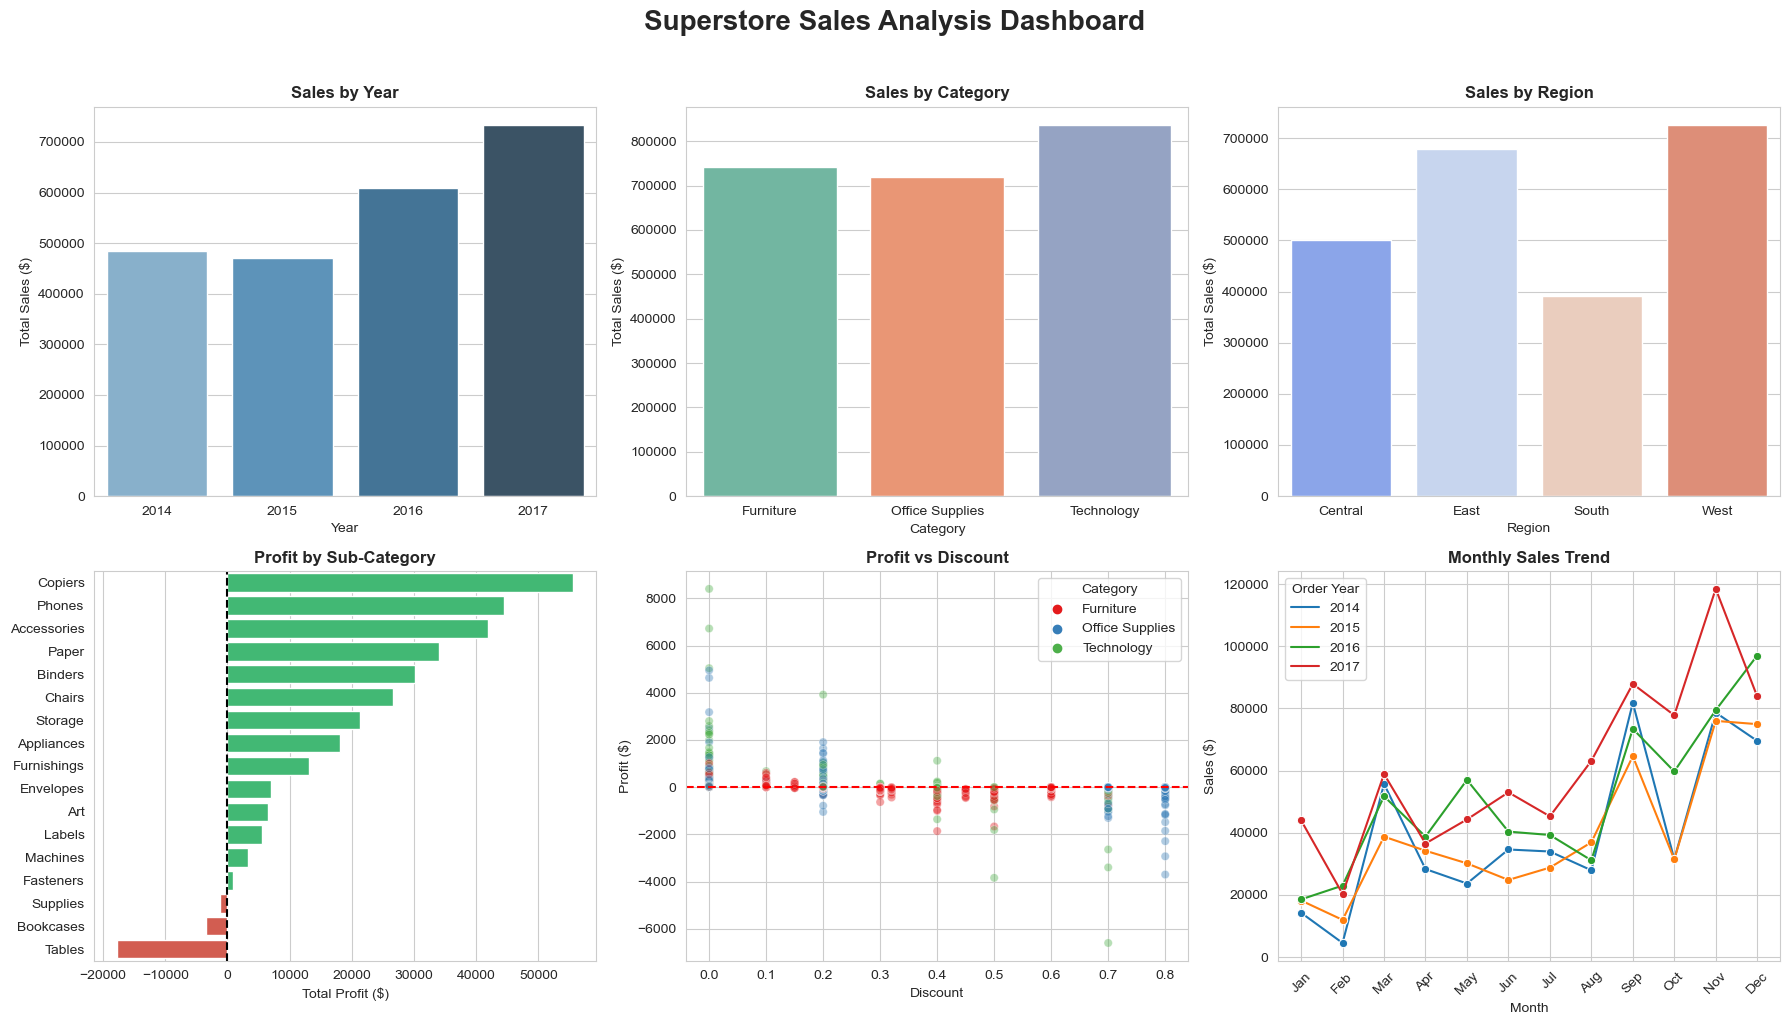

Dashboard saved as sales_dashboard.png!


In [104]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Superstore Sales Analysis Dashboard", 
             fontsize=20, fontweight="bold", y=1.02)

# --- Chart 1: Sales by Year ---
yearly_sales = df_sales.groupby("Order Year")["Sales"].sum().reset_index()
sns.barplot(ax=axes[0,0], data=yearly_sales, 
            x="Order Year", y="Sales", palette="Blues_d")
axes[0,0].set_title("Sales by Year", fontweight="bold")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Total Sales ($)")

# --- Chart 2: Sales by Category ---
category_sales = df_sales.groupby("Category")["Sales"].sum().reset_index()
sns.barplot(ax=axes[0,1], data=category_sales, 
            x="Category", y="Sales", palette="Set2")
axes[0,1].set_title("Sales by Category", fontweight="bold")
axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Total Sales ($)")

# --- Chart 3: Sales by Region ---
region_sales = df_sales.groupby("Region")["Sales"].sum().reset_index()
sns.barplot(ax=axes[0,2], data=region_sales, 
            x="Region", y="Sales", palette="coolwarm")
axes[0,2].set_title("Sales by Region", fontweight="bold")
axes[0,2].set_xlabel("Region")
axes[0,2].set_ylabel("Total Sales ($)")

# --- Chart 4: Profit by Sub-Category ---
sub_profit = df_sales.groupby("Sub-Category")["Profit"].sum()\
               .reset_index()\
               .sort_values("Profit", ascending=False)
colors = ["#2ecc71" if x > 0 else "#e74c3c" 
          for x in sub_profit["Profit"]]
sns.barplot(ax=axes[1,0], data=sub_profit, 
            x="Profit", y="Sub-Category", palette=colors)
axes[1,0].set_title("Profit by Sub-Category", fontweight="bold")
axes[1,0].axvline(x=0, color="black", linestyle="--")
axes[1,0].set_xlabel("Total Profit ($)")
axes[1,0].set_ylabel("")

# --- Chart 5: Discount vs Profit ---
sns.scatterplot(ax=axes[1,1], data=df_sales, x="Discount", 
                y="Profit", hue="Category", 
                alpha=0.4, palette="Set1")
axes[1,1].set_title("Profit vs Discount", fontweight="bold")
axes[1,1].axhline(y=0, color="red", linestyle="--")
axes[1,1].set_xlabel("Discount")
axes[1,1].set_ylabel("Profit ($)")

# --- Chart 6: Monthly Sales Trend ---
monthly_sales = df_sales.groupby(["Order Year","Order Month"])["Sales"]\
                  .sum().reset_index()
sns.lineplot(ax=axes[1,2], data=monthly_sales, 
             x="Order Month", y="Sales",
             hue="Order Year", marker="o", palette="tab10")
axes[1,2].set_title("Monthly Sales Trend", fontweight="bold")
axes[1,2].set_xticks(range(1,13))
axes[1,2].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                            "Jul","Aug","Sep","Oct","Nov","Dec"], 
                            rotation=45)
axes[1,2].set_xlabel("Month")
axes[1,2].set_ylabel("Sales ($)")

plt.tight_layout()
plt.savefig("sales_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as sales_dashboard.png!")

In [106]:
print(f"Total Sales: ${df_sales['Sales'].sum():,.2f}")
print(f"Total Profit: ${df_sales['Profit'].sum():,.2f}")
print(f"Total Orders: {df_sales['Order ID'].nunique()}")
print(f"Total Customers: {df_sales['Customer Name'].nunique()}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Total Customers: 793
